<a href="https://colab.research.google.com/github/Z0s-and-O1s/TNSIF_Training/blob/main/TNS_Supervied_learning_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

In [4]:
data = {
    "Age": [19, 18, 28, 33, 32, 31, 46, 37, 60, 25,
            40, 52, 23, 45, 36, 29, 50, 41, 27, 55,
            48, 30, 34, 26, 43, 39, 24, 58, 35, 47],

    "Sex": ["Female","Male","Male","Male","Male","Female","Female","Female","Male","Male",
            "Female","Male","Female","Male","Female","Male","Male","Female","Female","Male",
            "Female","Male","Male","Female","Male","Female","Male","Female","Male","Female"],

    "BMI": [27.9,33.7,33.0,22.7,28.8,25.7,33.4,27.7,36.0,26.2,
            29.5,31.4,24.8,35.2,30.5,27.3,34.1,28.9,23.6,37.4,
            32.8,25.9,29.7,22.5,31.0,26.8,24.3,35.5,28.2,33.1],

    "Children": [0,1,3,0,0,0,1,3,2,1,
                 2,3,0,2,1,0,3,2,1,4,
                 2,1,0,0,2,1,0,3,2,1],

    "Smoker": ["Yes","No","No","No","No","No","No","Yes","Yes","No",
               "Yes","No","No","Yes","No","No","Yes","No","No","Yes",
               "Yes","No","No","No","Yes","No","No","Yes","No","Yes"],

    "Region": ["Southwest","Southeast","Southeast","Northwest","Northwest","Southwest",
               "Southeast","Northeast","Southwest","Northwest",
               "Northeast","Southeast","Northwest","Southwest","Northeast",
               "Northwest","Southeast","Southwest","Northeast","Northwest",
               "Southeast","Southwest","Northeast","Northwest","Southeast",
               "Southwest","Northeast","Northwest","Southeast","Southwest"],

    "Charges": [16884,1725,4449,21984,3866,3756,8240,7281,45000,5200,
                25000,15000,3200,28000,9500,4100,36000,12000,5300,42000,
                31000,6200,7600,2900,27000,8500,3400,39000,6800,29500]
}

df = pd.DataFrame(data)

In [5]:
df

,Age,Sex,BMI,Children,Smoker,Region,Charges
0,19,Female,27.9,0,Yes,Southwest,16884
1,18,Male,33.7,1,No,Southeast,1725
2,28,Male,33.0,3,No,Southeast,4449
3,33,Male,22.7,0,No,Northwest,21984
4,32,Male,28.8,0,No,Northwest,3866
5,31,Female,25.7,0,No,Southwest,3756
6,46,Female,33.4,1,No,Southeast,8240
7,37,Female,27.7,3,Yes,Northeast,7281
8,60,Male,36.0,2,Yes,Southwest,45000
9,25,Male,26.2,1,No,Northwest,5200


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       30 non-null     int64  
 1   Sex       30 non-null     object 
 2   BMI       30 non-null     float64
 3   Children  30 non-null     int64  
 4   Smoker    30 non-null     object 
 5   Region    30 non-null     object 
 6   Charges   30 non-null     int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 1.8+ KB


In [9]:
df.describe()

,Age,BMI,Children,Charges
count,30.000000,30.000000,30.000000,30.000000
mean,37.033333,29.586667,1.366667,15346.166667
std,11.475561,4.184844,1.188547,13425.778151
min,18.000000,22.500000,0.000000,1725.000000
25%,28.250000,26.350000,0.000000,4636.750000
50%,35.500000,29.200000,1.000000,8370.000000
75%,45.750000,33.075000,2.000000,26500.000000
max,60.000000,37.400000,4.000000,45000.000000


In [12]:
df["High_Cost"] = (df["Charges"] > df["Charges"].median()).astype(int)

In [13]:
df.head()

,Age,Sex,BMI,Children,Smoker,Region,Charges,High_Cost
0,19,Female,27.9,0,Yes,Southwest,16884,1
1,18,Male,33.7,1,No,Southeast,1725,0
2,28,Male,33.0,3,No,Southeast,4449,0
3,33,Male,22.7,0,No,Northwest,21984,1
4,32,Male,28.8,0,No,Northwest,3866,0


In [14]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Sex"] = encoder.fit_transform(df["Sex"])
df["Smoker"] = encoder.fit_transform(df["Smoker"])
df["Region"] = encoder.fit_transform(df["Region"])

df.head()

,Age,Sex,BMI,Children,Smoker,Region,Charges,High_Cost
0,19,0,27.9,0,1,3,16884,1
1,18,1,33.7,1,0,2,1725,0
2,28,1,33.0,3,0,2,4449,0
3,33,1,22.7,0,0,1,21984,1
4,32,1,28.8,0,0,1,3866,0


In [15]:
df.corr(numeric_only=True)

,Age,Sex,BMI,Children,Smoker,Region,Charges,High_Cost
Age,1.000000,0.002764,0.706489,0.679159,0.580175,0.216559,0.818912,0.652918
Sex,0.002764,1.000000,0.186965,0.121978,-0.120165,0.024673,0.064716,-0.133631
BMI,0.706489,0.186965,1.000000,0.679734,0.584147,0.289741,0.680453,0.469882
Children,0.679159,0.121978,0.679734,1.000000,0.530766,0.089535,0.578623,0.427873
Smoker,0.580175,-0.120165,0.584147,0.530766,1.000000,0.153259,0.827205,0.622543
Region,0.216559,0.024673,0.289741,0.089535,0.153259,1.000000,0.222826,0.307729
Charges,0.818912,0.064716,0.680453,0.578623,0.827205,0.222826,1.000000,0.788758
High_Cost,0.652918,-0.133631,0.469882,0.427873,0.622543,0.307729,0.788758,1.000000


In [16]:
#  Simple Linear regressio

from sklearn.linear_model import LinearRegression
import plotly.express as px

X = df[["Age"]]
y = df["Charges"]

model = LinearRegression()
model.fit(X, y)

prediction = model.predict([[40]])

print("Predicted Charges:", prediction[0])

fig = px.scatter(
    df,
    x="Age",
    y="Charges",
    title="Simple Linear Regression",
    trendline="ols"
)

fig.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Predicted Charges: 18188.477074950468


In [17]:
# Multiple linear regression
from sklearn.linear_model import LinearRegression
import plotly.express as px

X = df[["Age","BMI","Children"]]
y = df["Charges"]

model = LinearRegression()
model.fit(X,y)

prediction = model.predict([[40,28,2]])

print("Predicted Charges:",prediction[0])

df["Predicted"] = model.predict(X)

fig = px.scatter(
    df,
    x="Charges",
    y="Predicted",
    title="Multiple Linear Regression"
)

fig.show()

Predicted Charges: 16344.039461550114


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



In [18]:
#  Random Forest
from sklearn.ensemble import RandomForestRegressor
import plotly.express as px

X = df[["Age","BMI","Children"]]
y = df["Charges"]

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X,y)

prediction = model.predict([[40,28,2]])

print("Predicted Charges:",prediction[0])

df["Predicted"] = model.predict(X)

fig = px.scatter(
    df,
    x="Charges",
    y="Predicted",
    title="Random Forest Regression"
)

fig.show()

Predicted Charges: 14580.86


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but RandomForestRegressor was fitted with feature names



In [19]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
import plotly.express as px

X = df[["Age"]]
y = df["High_Cost"]

model = LogisticRegression()

model.fit(X,y)

prediction = model.predict([[40]])

print("Prediction:",prediction[0])

fig = px.scatter(
    df,
    x="Age",
    y="High_Cost",
    color="High_Cost",
    title="Logistic Regression"
)

fig.show()

Prediction: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names



Predicted Charges: 25000.0


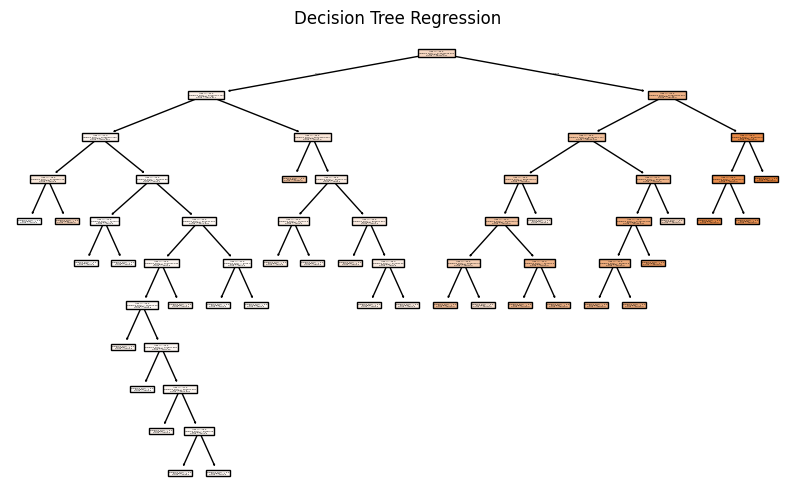

In [20]:
# Decision Tree
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

X = df[["Age"]]
y = df["Charges"]

model = DecisionTreeRegressor(random_state=42)

model.fit(X, y)

prediction = model.predict([[40]])

print("Predicted Charges:", prediction[0])

plt.figure(figsize=(10,6))
plot_tree(model, feature_names=["Age"], filled=True)
plt.title("Decision Tree Regression")
plt.show()

In [21]:
# SVM
from sklearn.svm import SVR
import plotly.express as px

X = df[["Age"]]
y = df["Charges"]

model = SVR(kernel="rbf")

model.fit(X, y)

prediction = model.predict([[40]])

print("Predicted Charges:", prediction[0])

df["Predicted"] = model.predict(X)

fig = px.scatter(
    df,
    x="Age",
    y="Predicted",
    title="Support Vector Regression"
)

fig.show()

Predicted Charges: 8368.397351803515


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but SVR was fitted with feature names



In [22]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
import plotly.express as px

X = df[["Age"]]
y = df["High_Cost"]

model = KNeighborsClassifier(n_neighbors=3)

model.fit(X, y)

prediction = model.predict([[40]])

print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("High Insurance Cost")
else:
    print("Low Insurance Cost")

fig = px.scatter(
    df,
    x="Age",
    y="High_Cost",
    color="High_Cost",
    title="KNN Classification"
)

fig.show()

Prediction: 1
High Insurance Cost


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but KNeighborsClassifier was fitted with feature names



In [23]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
import plotly.express as px

X = df[["Age"]]
y = df["High_Cost"]

model = GaussianNB()

model.fit(X, y)

prediction = model.predict([[40]])

print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("High Insurance Cost")
else:
    print("Low Insurance Cost")

fig = px.scatter(
    df,
    x="Age",
    y="High_Cost",
    color="High_Cost",
    title="Naive Bayes Classification"
)

fig.show()

Prediction: 1
High Insurance Cost


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but GaussianNB was fitted with feature names



Predicted Charges: 14730.981476839814


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but PolynomialFeatures was fitted with feature names

/tmp/ipykernel_4322/3582620814.py:23: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but PolynomialFeatures was fitted with feature names



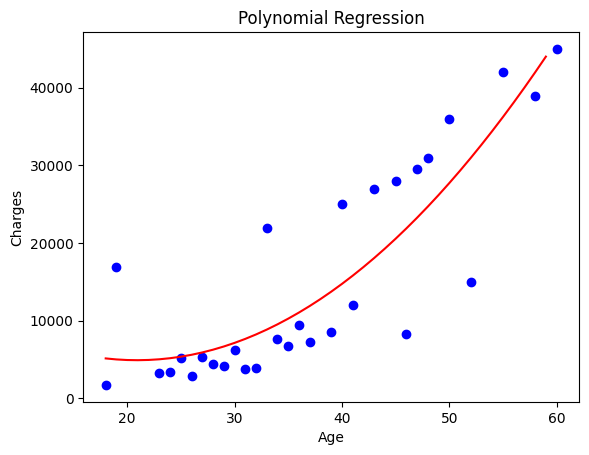

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt
import numpy as np

X = df[["Age"]]
y = df["Charges"]

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

model = LinearRegression()

model.fit(X_poly, y)

prediction = model.predict(poly.transform([[40]]))

print("Predicted Charges:", prediction[0])

plt.scatter(X, y, color="blue")

X_grid = np.arange(min(X.values), max(X.values), 1)
X_grid = X_grid.reshape(len(X_grid),1)

plt.plot(
    X_grid,
    model.predict(poly.transform(X_grid)),
    color="red"
)

plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Polynomial Regression")

plt.show()

In [27]:
# Step 1: Import Libraries

import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# Step 2: Create Dataset

df = pd.DataFrame({
    "Email":[
        "Congratulations! You won a free iPhone",
        "Meeting at 10 AM tomorrow",
        "Claim your lottery prize now",
        "Project submission is due today",
        "Limited time offer click here",
        "Happy Birthday! Have a great day",
        "Earn money from home instantly",
        "Your Amazon order has been shipped"
    ],

    "Spam":[
        1,
        0,
        1,
        0,
        1,
        0,
        1,
        0
    ]
})

print("Dataset")
print(df)

# Step 3: Input and Output

X = df["Email"]
y = df["Spam"]

# Step 4: Convert Text into Numbers

vectorizer = CountVectorizer()

X_vector = vectorizer.fit_transform(X)

# Step 5: Create Model

model = MultinomialNB()

# Step 6: Train Model

model.fit(X_vector, y)

# Step 7: Prediction

new_email = ["Congratulations! Claim your free lottery prize"]

new_email_vector = vectorizer.transform(new_email)

prediction = model.predict(new_email_vector)

# Step 8: Output

print("\nPrediction:", prediction[0])

if prediction[0] == 1:
    print("Spam Email")
else:
    print("Not Spam")

Dataset
                                    Email  Spam
0  Congratulations! You won a free iPhone     1
1               Meeting at 10 AM tomorrow     0
2            Claim your lottery prize now     1
3         Project submission is due today     0
4           Limited time offer click here     1
5        Happy Birthday! Have a great day     0
6          Earn money from home instantly     1
7      Your Amazon order has been shipped     0

Prediction: 1
Spam Email
